In [52]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder
from keras.src.layers import RandomFlip, RandomRotation, RandomZoom
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
import tensorflow as tf
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from keras.src.layers import BatchNormalization
from keras.src.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [46]:
samples = []
labels = []
size = []
data_path = r'C:\\Users\\mahdi\\Desktop\\machinlearning\\DEEP_Projects\\Lung_cancer_MobileNet\\The IQ-OTHNCCD lung cancer dataset'
for i in os.listdir(data_path):
    situation = os.path.join(data_path, i)
    le=0
    for j in os.listdir(situation):
        image_path = os.path.join(situation, j)
        image = Image.open(image_path).convert('RGB')
        image = image.resize((224, 224))
        image_array = np.asarray(image, dtype='float32')
        samples.append(image_array)
        labels.append(i)
        size.append(image.size)
        le+=1
    print(f"the number of {i} is {le}")

the number of Bengin cases is 587
the number of Malignant cases is 1611
the number of Normal cases is 832


In [48]:
encod = LabelEncoder()
labels = encod.fit_transform(labels)
samples = np.array(samples)
labels = np.array(labels)
x_train, x_test, y_train, y_test = train_test_split(samples, labels, test_size=0.2, random_state=42, stratify=labels)

In [49]:
x_train_normal = x_train/255
x_test_normal = x_test/255

In [68]:
# چاپ ترتیب دقیق کلاس‌ها در انکودر شما
print("ترتیب کلاس‌ها در انکودر:", encod.classes_)

ترتیب کلاس‌ها در انکودر: ['Bengin cases' 'Malignant cases' 'Normal cases']


In [51]:
class_weight = compute_class_weight(
    class_weight= 'balanced',
    classes = np.unique(y_train),
    y = y_train
)
class_weight_dict = dict(enumerate(class_weight))
print(class_weight_dict)

{0: np.float64(1.7228144989339018), 1: np.float64(0.6268425135764158), 2: np.float64(1.2132132132132132)}


In [63]:
model = Sequential()
img_height, img_width = 224, 224
model.add(RandomFlip("horizontal", input_shape = (img_height, img_width, 3)))
model.add(RandomRotation(0.1))
model.add(RandomZoom(0.1))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(224, 224, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(3, activation='softmax'))
opt = Adam(learning_rate=0.001)
model.compile(loss='sparse_categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

C:\Users\mahdi\Desktop\machinlearning\DEEP_Projects\Lung_cancer_MobileNet\.venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\mahdi\Desktop\machinlearning\DEEP_Projects\Lung_cancer_MobileNet\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    restore_best_weights=True
)

In [64]:
history = model.fit(x_train_normal, y_train, batch_size=32, epochs=150, validation_data=(x_test_normal, y_test), verbose=1)

Epoch 1/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 55s 692ms/step - accuracy: 0.5359 - loss: 1.4100 - val_accuracy: 0.6898 - val_loss: 0.7366
Epoch 2/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 47s 623ms/step - accuracy: 0.6642 - loss: 0.7410 - val_accuracy: 0.6947 - val_loss: 0.6839
Epoch 3/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 47s 622ms/step - accuracy: 0.6778 - loss: 0.7028 - val_accuracy: 0.6964 - val_loss: 0.6993
Epoch 4/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 47s 618ms/step - accuracy: 0.6881 - loss: 0.6756 - val_accuracy: 0.6881 - val_loss: 0.6605
Epoch 5/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 47s 622ms/step - accuracy: 0.7100 - loss: 0.6519 - val_accuracy: 0.6683 - val_loss: 0.7329
Epoch 6/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 47s 615ms/step - accuracy: 0.7125 - loss: 0.6471 - val_accuracy: 0.7145 - val_loss: 0.6066
Epoch 7/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 47s 621ms/step - accuracy: 0.7228 - loss: 0.6203 - val_accuracy: 0.7772 - val_loss: 0.5888
Epoch 8/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 47s 624ms/step - accuracy: 0.7331 - loss: 0.5935 - 

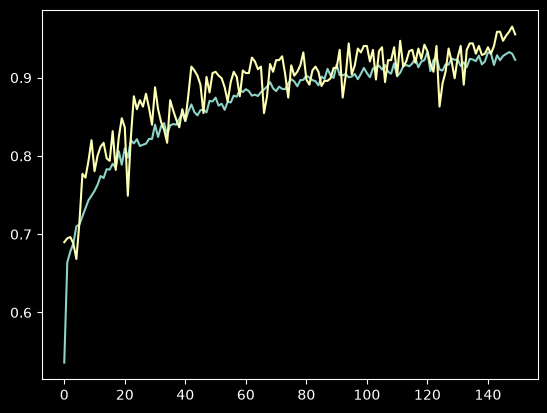

In [65]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

In [66]:
print("train:", history.history['accuracy'][-1])
print("val:", history.history['val_accuracy'][-1])

train: 0.9228547811508179
val: 0.9554455280303955


19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step


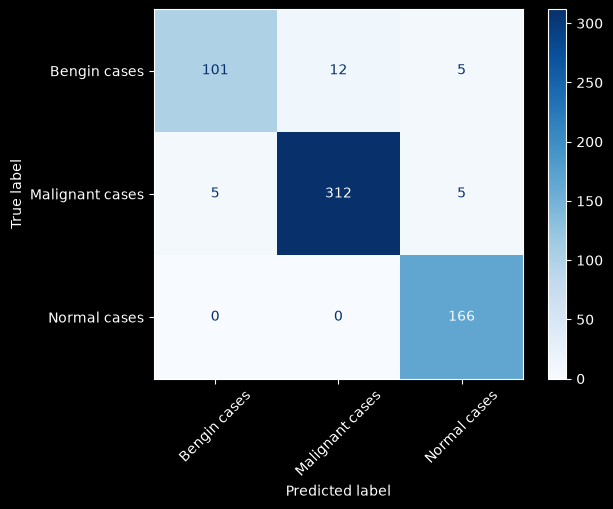

In [70]:
y_pred = model.predict(x_test_normal)
y_pred_class = np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_test, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encod.classes_)
disp.plot(cmap='Blues')
plt.xticks(rotation=45)
plt.show()

In [82]:
# ذخیره مدل با فرمت استاندارد کِراس
model.save('lung_cancer_mobilenet.keras')
print("مدل با موفقیت ذخیره شد! 🎉")

مدل با موفقیت ذخیره شد! 🎉


In [71]:
test_sample = []
test_label = []
test_path = r'C:\\Users\\mahdi\\Desktop\\machinlearning\\DEEP_Projects\\Lung_cancer_MobileNet\\data'
for cases in os.listdir(test_path):
    case = os.path.join(test_path, cases)
    for i in os.listdir(case):
        image_path = os.path.join(case, i)
        image = Image.open(image_path).convert('RGB')
        image = image.resize((224, 224))
        image_array = np.asarray(image, dtype='float32')
        test_sample.append(image_array)
        test_label.append(cases)

In [75]:
test_label= np.array(test_label)

In [79]:
print("اسم‌هایی که انکودر می‌شناسه:", encod.classes_)
print("اسم‌های موجود در دیتای تست شما:", np.unique(test_label))

اسم‌هایی که انکودر می‌شناسه: ['Benign' 'Malignant' 'Normal']
اسم‌های موجود در دیتای تست شما: ['Bengin' 'Malignant' 'Normal']


In [80]:
encod.fit(['Bengin', 'Malignant', 'Normal'])

# ۲. تبدیل لیبل‌ها و ادامه مراحل
test_label = encod.transform(test_label)
test_sample = np.array(test_sample)
test_label = np.array(test_label)
test_sample = test_sample/255

In [42]:
test_label.shape

(1933,)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step


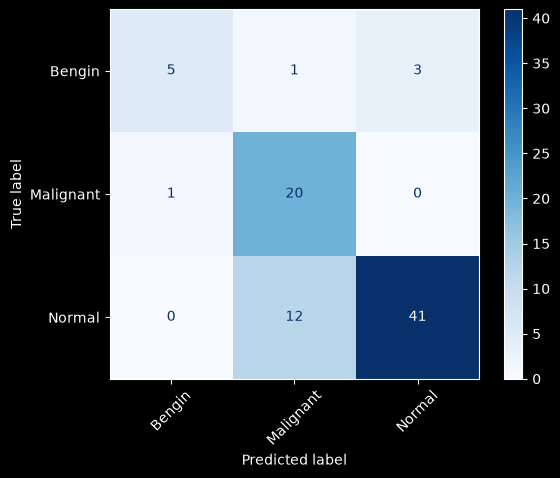

In [81]:
y_pred_test = model.predict(test_sample)
y_pred_test_class = np.argmax(y_pred_test, axis=1)
cm = confusion_matrix(test_label, y_pred_test_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encod.classes_)
disp.plot(cmap='Blues')
plt.xticks(rotation=45)
plt.show()